# Fundus → CIMT (Vascular Aging) Regression Model
**Goal:** Train a CNN to predict Carotid Intima-Media Thickness (CIMT) from paired left/right fundus photos.

CIMT is a well-established proxy for vascular/arterial aging and subclinical atherosclerosis. By training the model to learn this signature in the retina, the resulting model can later be applied to a separate cohort (e.g. young adults with hypercortisolism on metyrapone, no diagnosed cardiac disease) to see if their retinas show a similar "aged vasculature" signature — which would support the hypothesis that hypercortisolism accelerates vascular aging independent of overt CVD.

**Before running:** update the `CONFIG` cell below with your actual paths and CSV column names.


In [1]:
!pip install -q torch torchvision pandas scikit-learn matplotlib pillow

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


## 1. Find and unzip your dataset
Searches your Drive for `Fundus_CIMT_2903.zip` and extracts it into `/content/Fundus_CIMT_2903_DATASET`
(local Colab session storage -- fast to read from during training). Re-run this cell after every
runtime restart, since `/content` is wiped each time (Drive is not).


In [3]:
import glob
import zipfile
import os

zip_matches = glob.glob("/content/drive/MyDrive/**/Fundus_CIMT_2903.zip", recursive=True)
if not zip_matches:
    raise FileNotFoundError(
        "Couldn't find Fundus_CIMT_2903.zip anywhere in your Google Drive.\n"
        "Double check it finished uploading at drive.google.com (green checkmark, no spinner)."
    )

zip_path = zip_matches[0]
print("Found zip:", zip_path)

extract_to = "/content/Fundus_CIMT_2903_DATASET"
os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)

print("Extracted to:", extract_to)
print("Sample contents:", os.listdir(extract_to)[:10])


Found zip: /content/drive/MyDrive/Fundus_CIMT_2903.zip
Extracted to: /content/Fundus_CIMT_2903_DATASET
Sample contents: ['Fundus_CIMT_2903 Dataset']


## 2. Configuration
Update these paths/column names to match your dataset.


In [4]:
import os
import glob

IMAGE_DIR = "/content/Fundus_CIMT_2903_DATASET"

# If the zip extracted into a nested subfolder (common), find the real folder
# that actually contains the .png images
def find_real_image_dir(root):
    if any(f.lower().endswith(".png") for f in os.listdir(root)):
        return root
    for dirpath, dirnames, filenames in os.walk(root):
        if any(f.lower().endswith(".png") for f in filenames):
            return dirpath
    return root

IMAGE_DIR = find_real_image_dir(IMAGE_DIR)
print("Image folder:", IMAGE_DIR)

# data_info.csv lives in Drive (not inside the zip)
LABELS_PATH = "/content/drive/MyDrive/data_info.csv"
if not os.path.exists(LABELS_PATH):
    csv_matches = glob.glob("/content/drive/MyDrive/**/data_info.csv", recursive=True)
    if not csv_matches:
        raise FileNotFoundError("Couldn't find data_info.csv anywhere in your Google Drive.")
    LABELS_PATH = csv_matches[0]
print("Labels CSV:", LABELS_PATH)

CONFIG = {
    "IMAGE_DIR": IMAGE_DIR,
    "LABELS_PATH": LABELS_PATH,

    # Column in the CSV that holds the CIMT value (the regression target)
    "CIMT_KEY": "thickness",

    "IMG_SIZE": 224,
    "BATCH_SIZE": 16,
    "EPOCHS": 30,
    "LR": 1e-4,
    "VAL_SPLIT": 0.15,
    "TEST_SPLIT": 0.15,
    "SEED": 42,
    "CHECKPOINT_PATH": "/content/drive/MyDrive/best_model.pt",
}

print("Config set.")


Image folder: /content/Fundus_CIMT_2903_DATASET/Fundus_CIMT_2903 Dataset
Labels CSV: /content/drive/MyDrive/data_info.csv
Config set.


## 3. Load and inspect labels
Your labels come as a CSV file with columns for patient ID, e.g.:
```json
"2491006": {
    "gender": 0, "thickness": 0.8, "label": 0, "group": 1,
    "True_age": 63, "age": 0.68,
    "right_eye": "2491006_R.png", "left_eye": "2491006_L.png"
}
```
`thickness` is the CIMT value we'll use as the regression target, and `right_eye`/`left_eye` already give us the exact filenames to load.


In [5]:
import pandas as pd

labels_df = pd.read_csv(CONFIG["LABELS_PATH"])
print("Columns:", labels_df.columns.tolist())
print("Total rows:", len(labels_df))
labels_df.head()

Columns: ['patient_id', 'gender', 'thickness', 'label', 'group', 'True_age', 'age', 'right_eye', 'left_eye']
Total rows: 2903


,patient_id,gender,thickness,label,group,True_age,age,right_eye,left_eye
0,2491006,0,0.8,0,1,63,0.684932,2491006_R.png,2491006_L.png
1,3730004,1,1.2,1,1,61,0.657534,3730004_R.png,3730004_L.png
2,3730006,1,1.2,1,1,64,0.698630,3730006_R.png,3730006_L.png
3,4738005,0,0.7,0,1,53,0.547945,4738005_R.png,4738005_L.png
4,6528003,0,1.2,1,1,66,0.726027,6528003_R.png,6528003_L.png


In [6]:
labels_df.columns = [c.strip() for c in labels_df.columns]

# infer key columns regardless of exact naming
left_col = next(c for c in labels_df.columns if "left" in c.lower())
right_col = next(c for c in labels_df.columns if "right" in c.lower())
cimt_col = next(c for c in labels_df.columns if "thick" in c.lower() or "cimt" in c.lower())
pid_col = next((c for c in labels_df.columns if "id" in c.lower()), None)

labels_df[cimt_col] = pd.to_numeric(labels_df[cimt_col], errors="coerce")
print("Rows before dropping missing CIMT:", len(labels_df))
labels_df = labels_df.dropna(subset=[cimt_col])
print("Rows after dropping missing CIMT:", len(labels_df))

labels_df[[left_col, right_col, cimt_col]].head()


Rows before dropping missing CIMT: 2903
Rows after dropping missing CIMT: 2903


,left_eye,right_eye,thickness
0,2491006_L.png,2491006_R.png,0.8
1,3730004_L.png,3730004_R.png,1.2
2,3730006_L.png,3730006_R.png,1.2
3,4738005_L.png,4738005_R.png,0.7
4,6528003_L.png,6528003_R.png,1.2


## 4. Match each patient to their L/R image files
Uses the exact `left_eye` / `right_eye` filenames stored in the JSON (no need to guess a naming pattern). Patients whose image files aren't found on disk are skipped and listed.


In [7]:
records = []
missing = []

for _, row in labels_df.iterrows():
    left_path = os.path.join(CONFIG["IMAGE_DIR"], str(row[left_col]))
    right_path = os.path.join(CONFIG["IMAGE_DIR"], str(row[right_col]))
    if os.path.exists(left_path) and os.path.exists(right_path):
        records.append({
            "id": row[pid_col] if pid_col else len(records),
            "left": left_path,
            "right": right_path,
            "cimt": float(row[cimt_col]),
        })
    else:
        missing.append((row[left_col], row[right_col]))

print("Matched:", len(records), "| Missing:", len(missing))
if missing[:5]:
    print("Example missing filenames:", missing[:5])

if len(records) == 0:
    raise ValueError(
        "No images matched -- CONFIG['IMAGE_DIR'] is probably pointing to the wrong "
        "folder, or filenames in the CSV don't match actual files (check extension/case)."
    )


Matched: 2903 | Missing: 0


## 5. Train / validation / test split
Split is done at the **patient** level (not per-eye) to avoid leakage.


In [8]:
from sklearn.model_selection import train_test_split

train_records, temp_records = train_test_split(
    records, test_size=CONFIG["VAL_SPLIT"] + CONFIG["TEST_SPLIT"], random_state=CONFIG["SEED"]
)
val_records, test_records = train_test_split(
    temp_records,
    test_size=CONFIG["TEST_SPLIT"] / (CONFIG["VAL_SPLIT"] + CONFIG["TEST_SPLIT"]),
    random_state=CONFIG["SEED"],
)

print(f"Train: {len(train_records)} | Val: {len(val_records)} | Test: {len(test_records)}")


Train: 2032 | Val: 435 | Test: 436


## 6. Dataset and DataLoaders
Each sample stacks the left + right fundus image as a 6-channel input (2 x RGB), since CIMT is one value per patient rather than per eye.


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

train_transform = transforms.Compose([
    transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class FundusCIMTDataset(Dataset):
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        left_img = Image.open(rec["left"]).convert("RGB")
        right_img = Image.open(rec["right"]).convert("RGB")

        left_t = self.transform(left_img)
        right_t = self.transform(right_img)

        # Stack along channel dim -> 6 channels total
        combined = torch.cat([left_t, right_t], dim=0)
        target = torch.tensor(rec["cimt"], dtype=torch.float32)
        return combined, target


train_ds = FundusCIMTDataset(train_records, train_transform)
val_ds = FundusCIMTDataset(val_records, eval_transform)
test_ds = FundusCIMTDataset(test_records, eval_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=2)

print("DataLoaders ready.")


DataLoaders ready.


## 7. Model
ResNet50 pretrained on ImageNet, first conv layer adapted to accept 6 channels (L+R), final layer replaced with a single regression output.


In [10]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def build_model():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    # Adapt first conv layer: 3 channels -> 6 channels (duplicate pretrained weights for the extra 3)
    old_conv = model.conv1
    new_conv = nn.Conv2d(6, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                          stride=old_conv.stride, padding=old_conv.padding, bias=False)
    with torch.no_grad():
        new_conv.weight[:, :3] = old_conv.weight
        new_conv.weight[:, 3:] = old_conv.weight
    model.conv1 = new_conv

    # Replace final FC for regression (single CIMT value)
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, 1),
    )
    return model


model = build_model().to(device)
print("Model ready.")


Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 147MB/s]


Model ready.


In [11]:
import copy
import torch

criterion = nn.L1Loss()  # MAE
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["LR"], weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler(enabled=use_amp)

best_val_mae = float("inf")
history = {"train_loss": [], "val_loss": []}

for epoch in range(CONFIG["EPOCHS"]):
    model.train()
    running_loss = torch.tensor(0.0, device=device)
    for images, targets in train_loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            preds = model(images).squeeze(1)
            loss = criterion(preds, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.detach() * images.size(0)
    train_loss = (running_loss / len(train_ds)).item()

    model.eval()
    val_running = torch.tensor(0.0, device=device)
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                preds = model(images).squeeze(1)
                loss = criterion(preds, targets)
            val_running += loss.detach() * images.size(0)
    val_loss = (val_running / len(val_ds)).item()

    scheduler.step(val_loss)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch+1}/{CONFIG['EPOCHS']} | Train MAE: {train_loss:.4f} | Val MAE: {val_loss:.4f}")

    if val_loss < best_val_mae:
        best_val_mae = val_loss
        torch.save(model.state_dict(), CONFIG["CHECKPOINT_PATH"])
        print(f"  -> New best model saved (Val MAE: {val_loss:.4f})")

model.load_state_dict(torch.load(CONFIG["CHECKPOINT_PATH"], map_location=device))
print(f"Training complete. Best Val MAE: {best_val_mae:.4f}")

Epoch 1/30 | Train MAE: 0.2170 | Val MAE: 0.1646
  -> New best model saved (Val MAE: 0.1646)
Epoch 2/30 | Train MAE: 0.1596 | Val MAE: 0.1446
  -> New best model saved (Val MAE: 0.1446)
Epoch 3/30 | Train MAE: 0.1621 | Val MAE: 0.1718
Epoch 4/30 | Train MAE: 0.1499 | Val MAE: 0.1298
  -> New best model saved (Val MAE: 0.1298)
Epoch 5/30 | Train MAE: 0.1514 | Val MAE: 0.1476
Epoch 6/30 | Train MAE: 0.1457 | Val MAE: 0.1336
Epoch 7/30 | Train MAE: 0.1435 | Val MAE: 0.1491
Epoch 8/30 | Train MAE: 0.1424 | Val MAE: 0.1323
Epoch 9/30 | Train MAE: 0.1363 | Val MAE: 0.1275
  -> New best model saved (Val MAE: 0.1275)
Epoch 10/30 | Train MAE: 0.1329 | Val MAE: 0.1357
Epoch 11/30 | Train MAE: 0.1300 | Val MAE: 0.1276
Epoch 12/30 | Train MAE: 0.1296 | Val MAE: 0.1307
Epoch 13/30 | Train MAE: 0.1316 | Val MAE: 0.1271
  -> New best model saved (Val MAE: 0.1271)
Epoch 14/30 | Train MAE: 0.1328 | Val MAE: 0.1310
Epoch 15/30 | Train MAE: 0.1292 | Val MAE: 0.1347
Epoch 16/30 | Train MAE: 0.1236 | Val M

## 8. Training loop
Uses MAE loss (robust, and directly interpretable in mm of CIMT), Adam optimizer, and a learning-rate scheduler. Saves the best model (lowest validation MAE) to your Drive.


## 9. Plot training curves


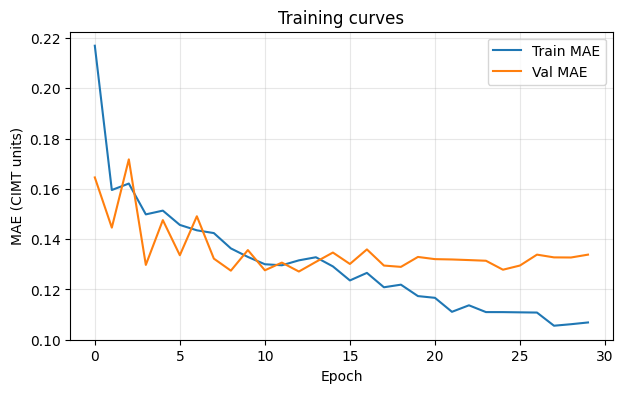

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="Train MAE")
plt.plot(history["val_loss"], label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE (CIMT units)")
plt.title("Training curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [13]:
import subprocess
print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)

Sun Jul 26 13:41:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             34W /   70W |    1415MiB /  15360MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 10. Evaluate on held-out test set


Test MAE: 0.1375
Test R^2: 0.1262


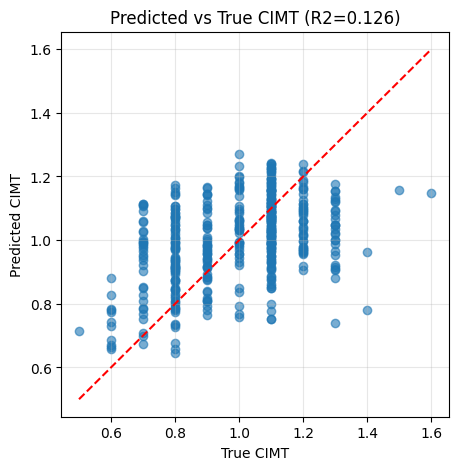

In [14]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        preds = model(images).squeeze(1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_targets.extend(targets.numpy().tolist())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

mae = mean_absolute_error(all_targets, all_preds)
r2 = r2_score(all_targets, all_preds)
print(f"Test MAE: {mae:.4f}")
print(f"Test R^2: {r2:.4f}")

plt.figure(figsize=(5, 5))
plt.scatter(all_targets, all_preds, alpha=0.6)
lims = [min(all_targets.min(), all_preds.min()), max(all_targets.max(), all_preds.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("True CIMT")
plt.ylabel("Predicted CIMT")
plt.title(f"Predicted vs True CIMT (R2={r2:.3f})")
plt.grid(alpha=0.3)
plt.show()


## 11. Next step: applying this to your hypercortisolism cohort
Once this model performs well on held-out CIMT-labeled data, you can run it on your separate cohort (high cortisol, on metyrapone, no diagnosed cardiac disease) using the cell below. It will output a **predicted "retinal vascular age" score** (i.e., what CIMT the retina resembles) — even though you have no ground-truth CIMT for that cohort, this gives you a comparable signature to correlate against cortisol levels.


In [15]:
def predict_new_patient(patient_id, image_dir=CONFIG["IMAGE_DIR"]):
    left_path = os.path.join(image_dir, f"{patient_id}_L.png")
    right_path = os.path.join(image_dir, f"{patient_id}_R.png")

    left_img = Image.open(left_path).convert("RGB")
    right_img = Image.open(right_path).convert("RGB")

    left_t = eval_transform(left_img)
    right_t = eval_transform(right_img)
    combined = torch.cat([left_t, right_t], dim=0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        pred = model(combined).item()
    return pred

# Example usage:
# predicted_cimt = predict_new_patient("1234567")
# print(f"Predicted vascular-age-equivalent CIMT: {predicted_cimt:.3f}")
